# Unit 4: EEG 信号特征提取与分析

## 学习目标

- 掌握频带功率 (δ/θ/α/β/γ) 的计算与解释
- 理解事件相关去同步/同步 (ERD/ERS) 的概念和量化方法
- 掌握共空间模式 (CSP) 特征提取算法
- 能够进行多通道 EEG 的 PSD 地形图分析
- 实现基本的 EEG 统计分析与可视化

---

## 4.1 频带功率分析

频带功率是 EEG 分析中最基本的特征。通过计算信号在各经典频段内的能量，可以推断大脑的功能状态。

### 功率谱密度 (PSD) 估计方法

| 方法 | 原理 | 优缺点 |
|------|------|--------|
| **Welch** | 分段加窗 FFT + 平均 | 方差小，分辨率固定 |
| **Multitaper** | 多 Slepian 窗 + 平均 | 最佳偏-方差权衡 |
| **Burg/AR** | 自回归模型 | 短数据效果好，需选择模型阶数 |

### 频带绝对功率与相对功率

- **绝对功率**：频段内的 PSD 积分，单位 μV²
- **相对功率**：频段功率 / 总功率，无量纲
- **相对功率** 对个体差异更稳健

Generating two conditions: Eyes Closed vs Eyes Open



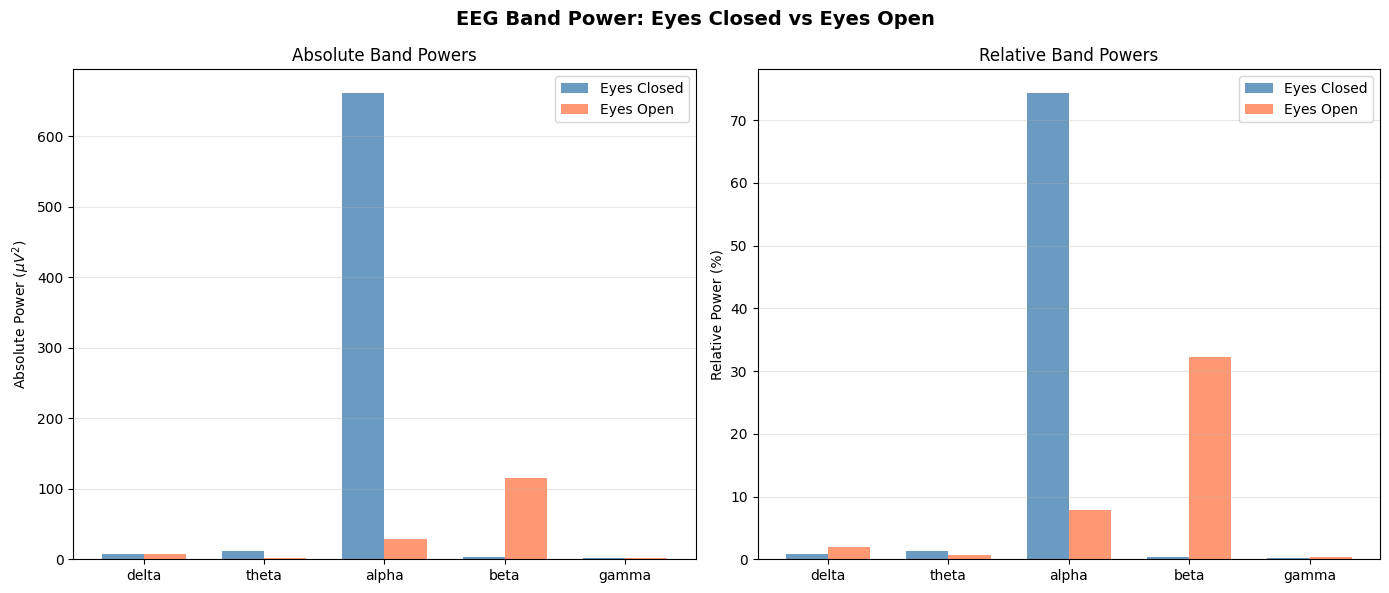


频带功率分析结果:
Band     Closed (abs)    Open (abs)      Closed (rel%)   Open (rel%)    
--------------------------------------------------------------------
delta    7.0572          6.8880          0.79            1.92           
theta    11.2690         2.2045          1.27            0.61           
alpha    661.6888        28.0908         74.40           7.82           
beta     3.3162          115.8472        0.37            32.25          
gamma    1.3379          1.3135          0.15            0.37           

关键观察:
- 闭眼时 alpha 相对功率显著高于睁眼 (alpha 阻断效应)
- 睁眼时 beta 相对功率升高 (视觉加工激活)


In [1]:
# ============================================================
# 代码 4.1: 频带功率分析-固定时间长度，固定采样点数
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from utils import generate_synthetic_eeg, compute_band_powers, BAND_COLORS



# 生成两种状态的数据：闭眼 (强 alpha) 和睁眼 (弱 alpha)
print("Generating two conditions: Eyes Closed vs Eyes Open\n")
SFREQ = 250.0
# 状态 1: 闭眼放松 (强 alpha)
eyes_closed, _ = generate_synthetic_eeg(
    duration=10.0, sfreq=SFREQ, n_channels=8,
    noise_level=5.0, alpha_power=50.0, seed=100
)

# 状态 2: 睁眼专注 (弱 alpha, 强 beta)
eyes_open, _ = generate_synthetic_eeg(
    duration=10.0, sfreq=SFREQ, n_channels=8,
    noise_level=5.0, alpha_power=10.0, seed=200
)
# 睁眼时 beta 相对功率升高 (视觉加工激活)
t = np.arange(eyes_open.shape[1]) / SFREQ
for ch in range(8):
    eyes_open[ch] += 15 * np.sin(2 * np.pi * 20 * t)  # beta 20Hz

# 计算频带功率
bands = {
    "delta": (0.5, 4), 
    "theta": (4, 8), 
    "alpha": (8, 13),
    "beta": (13, 30), 
    "gamma": (30, 45)
}

powers_closed = compute_band_powers(eyes_closed, SFREQ, bands)
powers_open = compute_band_powers(eyes_open, SFREQ, bands)

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 柱状图：绝对功率
x = np.arange(len(bands))
width = 0.35

closed_abs = [powers_closed[b]["absolute"] for b in bands]
open_abs = [powers_open[b]["absolute"] for b in bands]

axes[0].bar(
    x - width/2,      # x轴位置：向左偏移半个柱宽
    closed_abs,       # 柱状图高度：闭眼状态的绝对功率值
    width,            # 柱宽
    label="Eyes Closed",  # 图例标签
    color="steelblue",    # 柱体颜色：钢蓝色
    alpha=0.8             # 透明度：0.8
)
axes[0].bar(
    x + width/2,      # x轴位置：向右偏移半个柱宽
    open_abs,         # 柱状图高度：睁眼状态的绝对功率值
    width,            # 柱宽
    label="Eyes Open",  # 图例标签
    color="coral",      # 柱体颜色：红色
    alpha=0.8           # 透明度：0.8
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(bands.keys())
axes[0].set_ylabel("Absolute Power ($\mu V^2$)")
axes[0].set_title("Absolute Band Powers")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# 柱状图：相对功率
closed_rel = [powers_closed[b]["relative"] * 100 for b in bands]
open_rel = [powers_open[b]["relative"] * 100 for b in bands]

axes[1].bar(x - width/2, closed_rel, width, label="Eyes Closed",
            color="steelblue", alpha=0.8)
axes[1].bar(x + width/2, open_rel, width, label="Eyes Open",
            color="coral", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(bands.keys())
axes[1].set_ylabel("Relative Power (%)")
axes[1].set_title("Relative Band Powers")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("EEG Band Power: Eyes Closed vs Eyes Open",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n频带功率分析结果:")
print(f"{'Band':<8} {'Closed (abs)':<15} {'Open (abs)':<15} {'Closed (rel%)':<15} {'Open (rel%)':<15}")
print("-" * 68)
for band in bands:
    print(f"{band:<8} {powers_closed[band]['absolute']:<15.4f} "
          f"{powers_open[band]['absolute']:<15.4f} "
          f"{powers_closed[band]['relative']*100:<15.2f} "
          f"{powers_open[band]['relative']*100:<15.2f}")

print("\n关键观察:")
print("- 闭眼时 alpha 相对功率显著高于睁眼 (alpha 阻断效应)")
print("- 睁眼时 beta 相对功率升高 (视觉加工激活)")

## 4.2 事件相关去同步/同步 (ERD/ERS)

ERD/ERS 量化了特定频段能量相对于基线期的变化：

$$\text{ERD/ERS}(t) = \frac{P_{\text{active}}(t) - P_{\text{baseline}}}{P_{\text{baseline}}} \times 100\%$$


- **ERS (正值)**：事件后功率上升 → 皮层抑制（同步化）  
- **ERD (负值)**：事件后功率下降 → 皮层激活（去同步）   
静息时，运动皮层附近很多神经元会比较同步地振荡，所以 mu / beta 功率比较高。  
当你真的运动，或者想象运动时，相关运动皮层开始参与信息处理。神经元不再整齐地一起“闲置振荡”，而是各自参与不同的计算和放电活动，于是原来的同步节律被打散了。这就是为什么 ERD，也就是事件后功率下降，常被解释为皮层激活。


### 经典 ERD/ERS 范式

- **运动想象 (MI)**：对侧感觉运动区 α/β ERD
- **视觉刺激**：枕叶 α ERD
- **记忆编码**：额叶 θ ERS、枕叶 α ERD

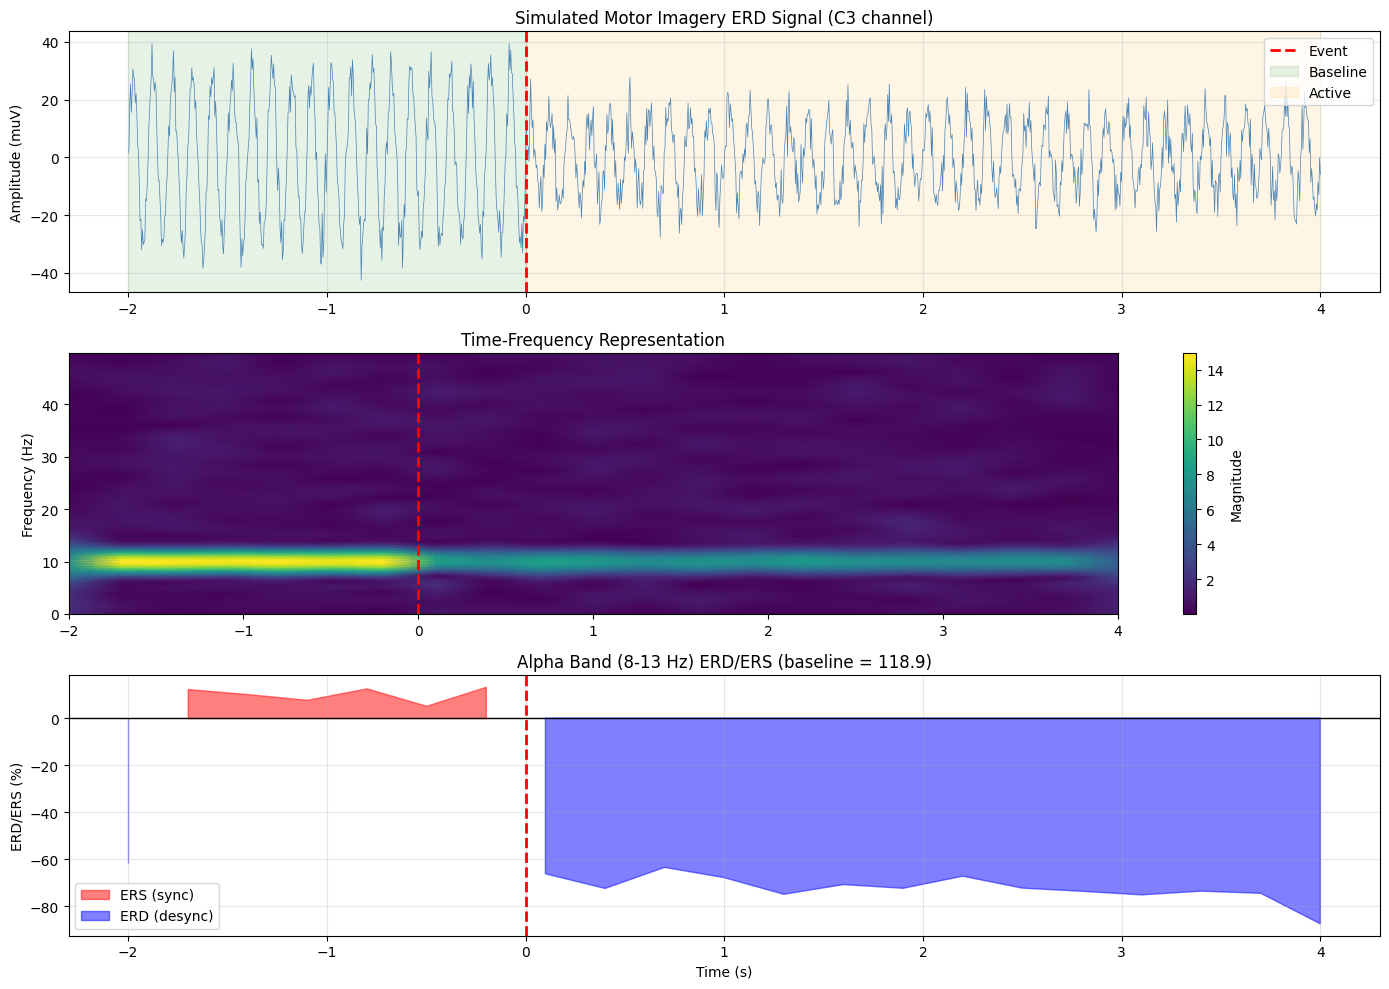

baseline ERD/ERS 平均值: -3.552713678800501e-15
基线期 alpha 功率: 118.91
活动期平均 ERD:     -72.3%


In [2]:
# ============================================================
# 代码 4.2: ERD/ERS 分析演示
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import gaussian_filter1d

SFREQ = 250.0

# 模拟运动想象 ERD
# 假设 C3 通道，基线期 [-2, 0]s, 运动想象期 [0, 4]s
t_total = 6.0  # 总时长: -2s to 4s
t_event = 2.0  # 事件时刻 (t=0 in epoch)
n_samples = int(t_total * SFREQ)
t_epoch = np.linspace(-2, 4, n_samples) # 时间轴

# 模拟 alpha (10Hz) 振荡，事件后功率下降 50%
rng = np.random.default_rng(42)
alpha_base_amp = 30.0
alpha_active_amp = 15.0  # 下降 50%
noise_level = 5.0

signal_erd = np.zeros(n_samples)
for i, t in enumerate(t_epoch):
    if t < 0:
        amp = alpha_base_amp # 基线期功率30muV
    else:
        amp = alpha_active_amp # 运动想象期功率15muV
    # freq 10Hz 为 alpha 振荡频率
    signal_erd[i] = amp * np.sin(2 * np.pi * 10 * t) + rng.normal(0, noise_level)

# 短时傅里叶变换计算时频功率
nperseg = int(0.5 * SFREQ)     # 滑动窗口大小500ms:每次拿 0.5 秒的数据量 做一次频谱分析
noverlap = int(0.4 * nperseg)  # 40% 重叠，即 200ms的数据量
f_stft, t_stft, Zxx = signal.stft(
    signal_erd, 
    fs=SFREQ, 
    nperseg=nperseg,
    noverlap=noverlap, 
    nfft=512
)
# f_stft shape: (n_wtimes,)
# t_stft shape: (n_wtimes,):STFT 时间窗的数量,不是时间点的数量
# Zxx shape: (n_freq, n_wtimes)

# 提取 alpha 频段 (8-13 Hz) 功率
alpha_mask = (f_stft >= 8) & (f_stft <= 13)
# 提取 alpha 播段的功率(alpha_freqs, n_wtimes)
# 再把 alpha 频段内多个频率点的功率平均成一个值(窗时间,)
alpha_power_t = np.mean(np.abs(Zxx[alpha_mask, :])**2, axis=0) 
t_stft_aligned = t_stft - t_event  # 对齐到事件的时间(窗时间)
# 原来的 STFT 时间点 - 事件发生时间 = 相对于事件的时间

# 计算 ERD/ERS (%)
# 计算 基线期的 alpha 平均功率
baseline_mask = t_stft_aligned < 0
# 截取 基线期的 alpha 功率(n_wtimes_base,)
# 再求 基线期的 alpha 的平均功率(标量)
baseline_power = np.mean(alpha_power_t[baseline_mask]) 
# 计算 ERD/ERS 百分比：相对于基线功率的变化率
# 公式: (当前功率 - 基线功率) / 基线功率 × 100%
# 结果为负表示 ERD（事件相关去同步），为正表示 ERS（事件相关同步）
erd_ers = (alpha_power_t - baseline_power) / baseline_power * 100

# 可视化
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. 时域信号
axes[0].plot(t_epoch, signal_erd, color="steelblue", linewidth=0.5)
axes[0].axvline(0, color="red", linestyle="--", linewidth=2, label="Event")
axes[0].axvspan(-2, 0, alpha=0.1, color="green", label="Baseline")
axes[0].axvspan(0, 4, alpha=0.1, color="orange", label="Active")
axes[0].set_ylabel("Amplitude (muV)")
axes[0].set_title("Simulated Motor Imagery ERD Signal (C3 channel)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. 时频图
im = axes[1].pcolormesh(
    t_stft_aligned,                # x轴：对齐到事件的时间(窗时间)
    f_stft[f_stft <= 50],          # y轴：频率轴，限制在50Hz以下
    np.abs(Zxx[f_stft <= 50, :]),  # 颜色映射值：STFT结果的幅值，频率限制在50Hz以下
    shading="gouraud",             # 着色方式：Gouraud平滑着色，使颜色过渡更平滑
    cmap="viridis"                 # 颜色映射：使用viridis colormap，从紫色到黄色的渐变色
)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title("Time-Frequency Representation")
plt.colorbar(im, ax=axes[1], label="Magnitude")

# 3. ERD/ERS 曲线
axes[2].fill_between(
    t_stft_aligned,  # x轴：对齐到事件的时间(窗时间)
    0,               # y轴下限
    erd_ers,         # y轴上限：ERD/ERS百分比
    where=(erd_ers >= 0),  # 条件：ERS（同步）区域
    color="red",     # 颜色：红色表示ERS
    alpha=0.5,       # 透明度：50%
    label="ERS (sync)"
)
axes[2].fill_between(
    t_stft_aligned,  # x轴：对齐到事件的时间(窗时间)
    0,               # y轴下限
    erd_ers,         # y轴上限：ERD/ERS百分比
    where=(erd_ers < 0),  # 条件：ERD（去同步）区域
    color="blue",    # 颜色：蓝色表示ERD
    alpha=0.5,
    label="ERD (desync)"
)
axes[2].axhline(0, color="black", linestyle="-", linewidth=1)
axes[2].axvline(0, color="red", linestyle="--", linewidth=2)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("ERD/ERS (%)")
axes[2].set_title(f"Alpha Band (8-13 Hz) ERD/ERS (baseline = {baseline_power:.1f})")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("baseline ERD/ERS 平均值:",
      np.mean(erd_ers[baseline_mask]))
print(f"基线期 alpha 功率: {baseline_power:.2f}")
print(f"活动期平均 ERD:     {np.mean(erd_ers[t_stft_aligned > 0]):.1f}%")

## 4.3 共空间模式 (CSP) — BCI 的核心特征算法

CSP 是运动想象 BCI 中最经典的空域滤波算法。其目标是找到一个投影矩阵 $W$，使得：

- 投影后，一类信号的方差最大化，另一类最小化

### 数学原理

对于两类协方差矩阵 $\Sigma_1$ 和 $\Sigma_2$：

$$w^* = \arg\max_w \frac{w^T \Sigma_1 w}{w^T (\Sigma_1 + \Sigma_2) w}$$

这等价于解广义特征值问题 $\Sigma_1 w = \lambda (\Sigma_1 + \Sigma_2) w$。

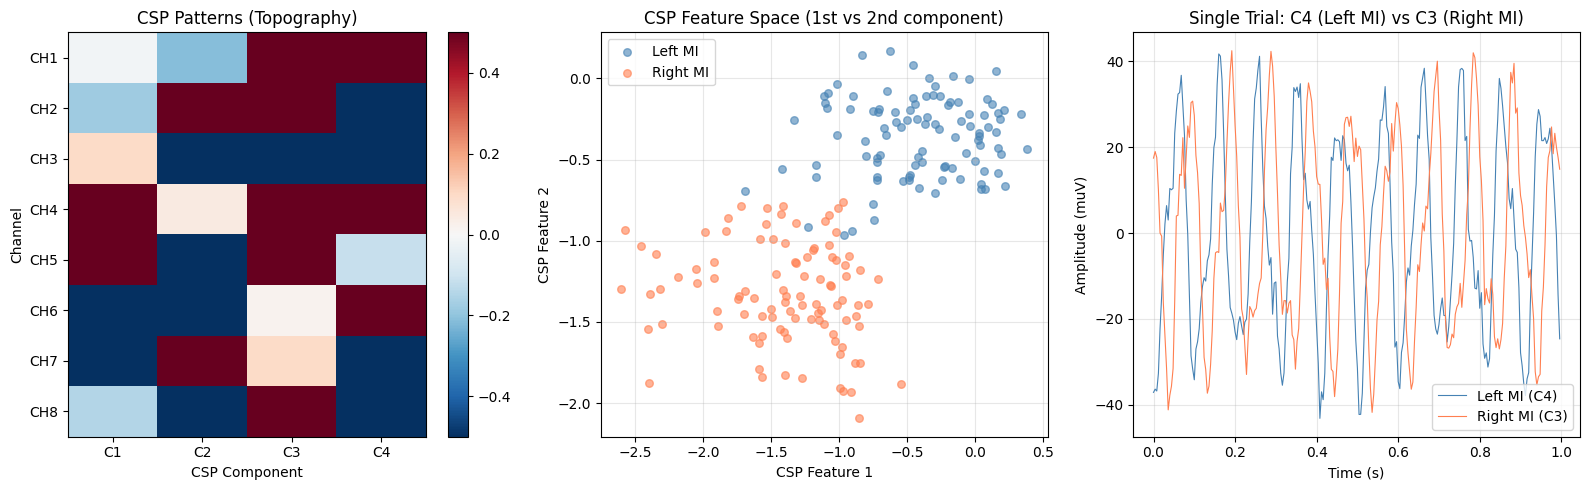

CSP 特征提取结果:
  Left MI  - Feature 1 mean: -0.410
  Right MI - Feature 1 mean: -1.404
  Feature 1 区分度 (Cohen's d): -2.19


In [3]:
# ============================================================
# 代码 4.3: CSP 算法实现与演示
# ============================================================
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt


class CSP:
    """
    Common Spatial Patterns (CSP) 特征提取器。
    
    经典的二分类空域滤波算法，广泛应用于运动想象 BCI。
    提取使两类方差差异最大化的空间滤波器。
    """
    
    def __init__(self, n_components=4):
        """
        Parameters
        ----------
        n_components : int
            保留的 CSP 成分数（前 n/2 和后 n/2 各取一半）
        """
        self.n_components = n_components
        self.filters = None
        self.patterns = None
    
    def fit(self, X_class1, X_class2):
        """
        训练 CSP 滤波器。
        
        Parameters
        ----------
        X_class1 : ndarray (n_trials, n_channels, n_samples)
            类别 1 的 trial 数据
        X_class2 : ndarray (n_trials, n_channels, n_samples)
            类别 2 的 trial 数据
        """
        n_channels = X_class1.shape[1]
        
        # 计算平均协方差矩阵
        # 默认情况下，np.cov() 会把 每一行当作一个变量，把 每一列当作一次观测值
        # np.cov(trial).shape: (n_channels, n_channels) 通道 × 通道
        # cov[i, j] = 第 i 个通道和第 j 个通道之间的协方差
        # [np.cov(trial) for trial in X_class1] 是一个列表，每个元素是一个通道的协方差矩阵:(n_trials, n_channels, n_channels)
        # 再对每个trial的协方差矩阵求平均，得到平均协方差矩阵:(n_channels, n_channels)
        cov1 = np.mean([np.cov(trial) for trial in X_class1], axis=0)
        cov2 = np.mean([np.cov(trial) for trial in X_class2], axis=0)
        
        # 正则化（避免奇异）
        """
        [[0.000001, 0,        0,       ...],
        [0,        0.000001, 0,       ...],
        [0,        0,        0.000001,...],
        ...]
        """
        cov1 += 1e-6 * np.eye(n_channels)
        cov2 += 1e-6 * np.eye(n_channels)
        
        # 解广义特征值问题
        eigvals, eigvecs = eigh(cov1, cov1 + cov2)
        
        # 按特征值排序（降序）
        idx = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, idx]
        
        # 保留前 n/2 和后 n/2 个特征向量
        half = self.n_components // 2
        selected = np.hstack([eigvecs[:, :half], eigvecs[:, -half:]])
        
        # 计算 CSP 滤波器（空间模式）
        self.filters = selected.T  # (n_components, n_channels)
        # # 空间模式（用于可视化）
        self.patterns = np.linalg.pinv(selected).T  # (n_channels, n_components)
        
        return self
    
    def transform(self, X):
        """
        应用 CSP 滤波器提取特征。
        
        Parameters
        ----------
        X : ndarray (n_trials, n_channels, n_samples)
            
        Returns
        -------
        features : ndarray (n_trials, n_components)
            CSP 特征 = log(variance of each filtered signal)
        """
        features = []
        for trial in X:
            # 计算滤波后的信号
            # (n_components, n_channels) @ (n_channels, n_samples) = (n_components, n_samples)
            filtered = self.filters @ trial  # (n_components, n_samples)
            # 特征 = log(方差)
            feat = np.log(np.var(filtered, axis=1) + 1e-10)
            features.append(feat)
        return np.array(features)  # (n_trials, n_components)


# ---- 生成模拟运动想象数据 ----
rng = np.random.default_rng(42)
n_channels = 8
n_trials = 100
n_samples = 250  # 1 秒 x 250 Hz

# 模拟 CSP 模式：左侧 MI → C4 alpha ERD；右侧 MI → C3 alpha ERD
# 使用简化的空间模式（实际数据中模式来自真实神经源）

def generate_mi_trials(n_trials, active_ch, n_channels=8, n_samples=250):
    """
    生成运动想象 trial 数据。
    
    active_ch: 激活的通道（alpha 抑制更强）
    """
    trials = np.zeros((n_trials, n_channels, n_samples))
    t = np.arange(n_samples) / 250.0
    
    for tr in range(n_trials):
        for ch in range(n_channels):
            # 空间衰减模式：离 active_ch 越近，alpha 抑制越强
            distance = abs(ch - active_ch)
            alpha_amp = 30 * np.exp(-distance / 2)  # 高斯衰减
            beta_amp = 10 * np.exp(-distance / 3)
            
            noise = rng.normal(0, 3, n_samples)
            alpha = alpha_amp * np.sin(2 * np.pi * 10 * t + rng.uniform(0, 2*np.pi))
            beta = beta_amp * np.sin(2 * np.pi * 22 * t + rng.uniform(0, 2*np.pi))
            
            trials[tr, ch] = alpha + beta + noise
    
    return trials  # (n_trials, n_channels, n_samples)


# 类别 1: 左侧 MI (C4=CH3, index 3)
X_left = generate_mi_trials(n_trials, active_ch=3) # (n_trials, n_channels, n_samples)
# 类别 2: 右侧 MI (C3=CH2, index 2)
X_right = generate_mi_trials(n_trials, active_ch=2) # (n_trials, n_channels, n_samples)

# 训练 CSP
csp = CSP(n_components=4)
csp.fit(X_left, X_right)

# 提取特征
features_left = csp.transform(X_left) # (n_trials, 4)
features_right = csp.transform(X_right) # (n_trials, 4)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. CSP 模式（地形图）
im1 = axes[0].imshow(
    csp.patterns[:, :4], # shape (n_channels, 4) 矩阵的行作y轴，列作x轴
    aspect="auto", 
    cmap="RdBu_r",
    vmin=-0.5, 
    vmax=0.5
)
axes[0].set_xlabel("CSP Component")
axes[0].set_ylabel("Channel")
axes[0].set_title("CSP Patterns (Topography)")
axes[0].set_yticks(range(n_channels))
axes[0].set_yticklabels([f"CH{i+1}" for i in range(n_channels)]) # 通道标签:y轴
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(["C1", "C2", "C3", "C4"]) # CSP 成分标签:x轴
plt.colorbar(im1, ax=axes[0])

# 2. 特征分布（前 2 个 CSP 成分）
# 绘制CSP特征散点图，展示两类运动想象任务在特征空间的分布
axes[1].scatter(
    features_left[:, 0],  # 第一个 CSP 特征（方差对数）
    features_left[:, 1],  # 第二个 CSP 特征（方差对数）
    c="steelblue",        # 颜色：钢蓝色
    alpha=0.6,            # 透明度
    label="Left MI",      # 图例标签
    s=30                  # 散点大小
)
axes[1].scatter(
    features_right[:, 0],  # 第一个 CSP 特征（方差对数）
    features_right[:, 1],  # 第二个 CSP 特征（方差对数）
    c="coral",        # 颜色：红色
    alpha=0.6,            # 透明度
    label="Right MI",      # 图例标签
    s=30                  # 散点大小
)
axes[1].set_xlabel("CSP Feature 1")
axes[1].set_ylabel("CSP Feature 2")
axes[1].set_title("CSP Feature Space (1st vs 2nd component)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. 单 trial 原始信号对比
t_trial = np.arange(n_samples) / SFREQ
axes[2].plot(t_trial, X_left[0, 3], color="steelblue", label="Left MI (C4)", linewidth=0.8) # 通道3
axes[2].plot(t_trial, X_right[0, 2], color="coral", label="Right MI (C3)", linewidth=0.8)   # 通道2
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude (muV)")
axes[2].set_title("Single Trial: C4 (Left MI) vs C3 (Right MI)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("CSP 特征提取结果:")
print(f"  Left MI  - Feature 1 mean: {features_left[:, 0].mean():.3f}")
print(f"  Right MI - Feature 1 mean: {features_right[:, 0].mean():.3f}")


# Cohen's d 通常用 pooled standard deviation
x_right = features_right[:, 0]
x_left = features_left[:, 0]

n_right = len(x_right)
n_left = len(x_left)

mean_diff = x_right.mean() - x_left.mean()

std_right = np.std(x_right, ddof=1)
std_left = np.std(x_left, ddof=1)

pooled_std = np.sqrt(
    ((n_right - 1) * std_right ** 2 + (n_left - 1) * std_left ** 2)
    / (n_right + n_left - 2)
)

pooled_std = max(pooled_std, 1e-6)

cohens_d = mean_diff / pooled_std

print(f"  Feature 1 区分度 (Cohen's d): {cohens_d:.2f}")


## 4.4 多通道频谱分析与地形图

将各通道的频带功率映射到头皮上，称为 EEG 地形图 (Topographic Map)。
这是临床 EEG 和 BCI 研究中的标准可视化工具。

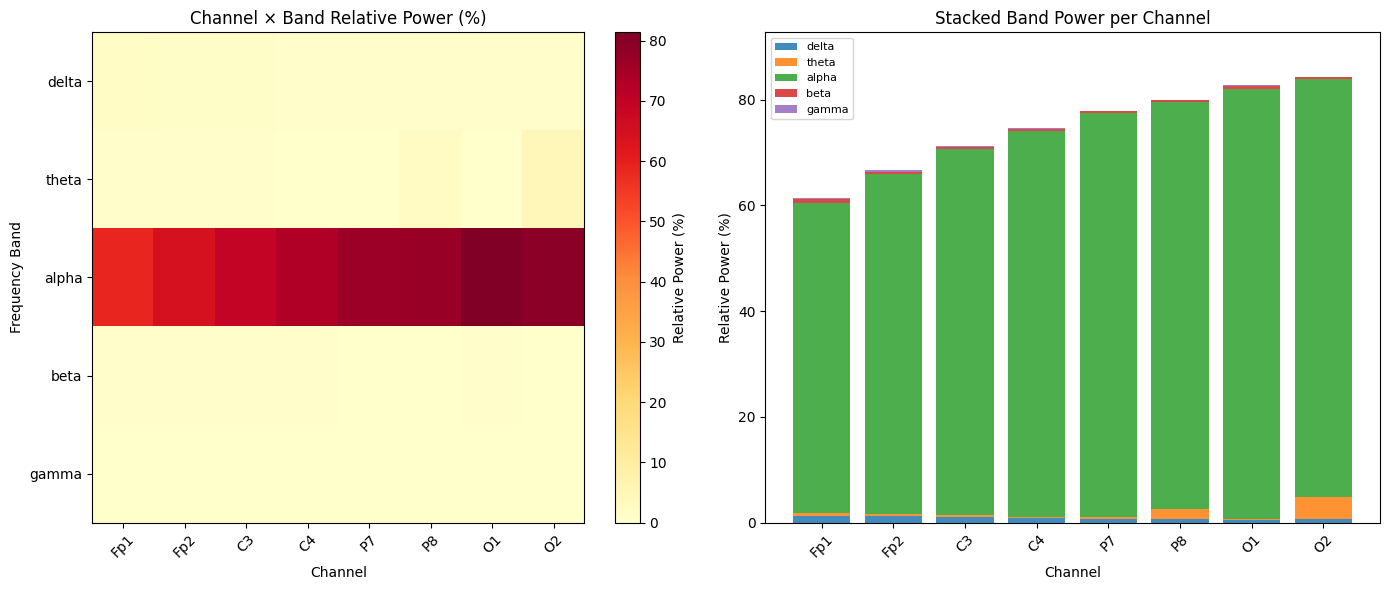

通道-频段相对功率矩阵 (%):
Channel      delta   theta   alpha    beta   gamma
--------------------------------------------------
Fp1           1.33    0.42   58.79    0.65    0.25
Fp2           1.25    0.38   64.32    0.46    0.22
C3            1.03    0.50   69.09    0.41    0.18
C4            0.84    0.28   73.01    0.36    0.17
P7            0.77    0.23   76.50    0.29    0.15
P8            0.60    1.94   77.08    0.26    0.13
O1            0.56    0.19   81.36    0.54    0.12
O2            0.59    4.20   79.23    0.21    0.10


In [ ]:
# ============================================================
# 代码 4.4: PSD 多通道对比与频段能量分布
# ============================================================
from utils import compute_band_powers, BAND_COLORS, CYTON_8CH_1020_MAP

# 使用前面的 eyes_closed 数据
# 逐通道计算频带相对功率
band_names = ["delta", "theta", "alpha", "beta", "gamma"]
bands = {"delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 13),
         "beta": (13, 30), "gamma": (30, 45)}

n_ch = eyes_closed.shape[0] # channels
channel_rel_powers = np.zeros((n_ch, len(band_names))) # (channels, bands)

# 计算每个通道每个频带的相对功率
for ch in range(n_ch):
    powers = compute_band_powers(eyes_closed[ch:ch+1], SFREQ, bands)
    for j, band in enumerate(band_names):
        channel_rel_powers[ch, j] = powers[band]["relative"] * 100 # (channel, band_relative_power)

# 热力图：通道 × 频段
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左: 热力图 (bands, channels)
im = axes[0].imshow(channel_rel_powers.T, aspect="auto", cmap="YlOrRd",
                     vmin=0, vmax=channel_rel_powers.max() * 1)
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Frequency Band")
axes[0].set_title("Channel × Band Relative Power (%)")
axes[0].set_xticks(range(n_ch))
axes[0].set_xticklabels(
    [CYTON_8CH_1020_MAP.get(i+1, f"CH{i+1}") for i in range(n_ch)], 
    rotation=45
)
axes[0].set_yticks(range(len(band_names)))
axes[0].set_yticklabels(band_names)
plt.colorbar(im, ax=axes[0], label="Relative Power (%)")

# 右: 堆叠柱状图
x = np.arange(n_ch)
bottom = np.zeros(n_ch)
for j, band in enumerate(band_names):
    axes[1].bar(x, channel_rel_powers[:, j], bottom=bottom,
                color=BAND_COLORS[band], label=band, alpha=0.85)
    bottom += channel_rel_powers[:, j]

axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Relative Power (%)")
axes[1].set_title("Stacked Band Power per Channel")
axes[1].set_xticks(x)
axes[1].set_xticklabels([CYTON_8CH_1020_MAP.get(i+1, f"CH{i+1}")
                          for i in range(n_ch)], rotation=45)
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, np.sum(channel_rel_powers, axis=1).max() * 1.1)

plt.tight_layout()
plt.show()

print("通道-频段相对功率矩阵 (%):")
header = f"{'Channel':<10}" + "".join([f"{b:>8}" for b in band_names])
print(header)
print("-" * (10 + 8 * len(band_names)))
for ch in range(n_ch):
    name = CYTON_8CH_1020_MAP.get(ch+1, f"CH{ch+1}")
    vals = "".join([f"{channel_rel_powers[ch, j]:>8.2f}" for j in range(len(band_names))])
    print(f"{name:<10}{vals}")

## 单元小结

本单元涵盖：
1. 频带功率（绝对和相对）的计算与两种状态对比
2. ERD/ERS 分析流程：基线计算 → 时频功率 → 百分比变化
3. CSP 空域滤波器的数学原理、代码实现和特征提取
4. 多通道频谱分析：通道×频段热力图与堆叠柱状图

**下一步：** Unit 5 将结合 CSP 特征和分类器构建完整的 BCI 系统。